# **RESOLUÇÃO DO DESAFIO**

In [10]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 55.3 MB/s eta 0:00:00


In [11]:
import mysql.connector

conn = mysql.connector.connect(host="35.199.115.174",
    port=3306,
    user='looqbox-challenge',
    password='looq-challenge',
    database='looqbox-challenge')

print('Banco de dados conectado')

Banco de dados conectado


In [40]:
import mysql.connector
import pandas as pd

query = 'SHOW TABLES;'

df = pd.read_sql(query, conn)
print(df)


/tmp/ipykernel_2488/146329309.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  Tables_in_looqbox-challenge
0                 IMDB_movies
1                data_product
2          data_product_sales
3              data_store_cad
4            data_store_sales


**QUESTÃO 1 - QUAIS SÃO OS 10 PRODUTOS MAIS CAROS DA EMPRESA?**

In [13]:
query = 'SELECT * FROM data_product ORDER BY PRODUCT_VAL DESC LIMIT 10;'
df = pd.read_sql(query, conn)
print(df)



/tmp/ipykernel_2488/533567683.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   PRODUCT_COD                                       PRODUCT_NAME  \
0       301409  Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...   
1       176185  Whisky Escoces JOHNNIE WALKER Blue Label Garra...   
2       315481   Cafeteira Expresso 3 CORACOES Tres Modo Vermelho   
3       100280  Vinho Portugues Tinto Vintage QUINTA DO CRASTO...   
4       320046  Escova Dental Eletrica ORAL B D34 Professional...   
5       190817  Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...   
6       153795  Champagne Frances Brut Imperial MOET Rose Garr...   
7       311397  Conjunto de Panelas Allegra em Inox TRAMONTINA...   
8       147706  Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml   
9       154431  Champagne Frances Brut Imperial MOET & CHANDON...   

   PRODUCT_VAL    DEP_NAME  DEP_COD        SECTION_NAME  SECTION_COD  
0       741.99     BEBIDAS        2             BEBIDAS            4  
1       735.90     BEBIDAS        2             BEBIDAS            4  
2       499.00     BEBIDAS 


**QUESTÃO 2 - QUAIS SEÇÕES EXISTEM NOS DEPARTAMENTOS "BEBIDAS" E "PADARIA"?**

In [14]:
query = "SELECT DISTINCT SECTION_NAME, DEP_NAME FROM data_product WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA');"
df = pd.read_sql(query, conn)
print(df)

/tmp/ipykernel_2488/264300616.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


         SECTION_NAME DEP_NAME
0             BEBIDAS  BEBIDAS
1              VINHOS  BEBIDAS
2  DOCES-E-SOBREMESAS  PADARIA
3     QUEIJOS-E-FRIOS  PADARIA
4            CERVEJAS  BEBIDAS
5             PADARIA  PADARIA
6           REFRESCOS  BEBIDAS
7            GESTANTE  PADARIA


**QUESTÃO 3 - QUAL O TOTAL DE VENDAS EM $ DE CADA ÁREA DE NEGÓCIO NO PRIMEIRO TRIMESTRE DE 2019?**

In [15]:
query = 'SELECT * FROM data_store_cad LIMIT 5;'
df = pd.read_sql(query, conn)
print(df)

/tmp/ipykernel_2488/500136829.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   STORE_CODE STORE_NAME  START_DATE END_DATE BUSINESS_NAME  BUSINESS_CODE
0           1  Sao Paulo  2006-10-01                 Varejo              1
1           2    Chicago  2007-10-01                 Varejo              1
2           3       Roma  2008-10-01                 Varejo              1
3           4      Tokio  2009-10-01                 Varejo              1
4           5      Paris  2019-01-01            Proximidade              2


In [76]:
query = """
SELECT sc.BUSINESS_NAME, SUM(ps.SALES_VALUE) AS TOTAL_VENDAS
FROM data_product_sales ps
JOIN data_store_cad sc ON ps.STORE_CODE = sc.STORE_CODE
WHERE ps.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY sc.BUSINESS_NAME;
"""
df = pd.read_sql(query, conn)
print(df)

/tmp/ipykernel_2488/2308394804.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  BUSINESS_NAME  TOTAL_VENDAS
0        Varejo   81032347.65
1         Farma   81776691.73
2       Atacado   80384884.60
3         Posto   32072326.40
4   Proximidade   80171122.80


**CASO 1 -  FILTRO DE PESQUISA PARA ITENS DE LISTA:**

In [42]:
def retrieve_data(product_code, store_code, date):

    if isinstance(product_code, int):
        product_code = [product_code]
    if isinstance(store_code, int):
        store_code = [store_code]

    product_str = ', '.join(str(x) for x in product_code)
    store_str = ', '.join(str(x) for x in store_code)

    query = f"""
    SELECT * FROM data_product_sales
    WHERE PRODUCT_CODE IN ({product_str})
    AND STORE_CODE IN ({store_str})
    AND DATE BETWEEN '{date[0]}' AND '{date[1]}'
    """

    df = pd.read_sql(query, conn)
    return df


In [62]:
pesquisa = retrieve_data([18, 48, 172], [1, 2, 3, 4], ['2019-01-01', '2019-03-31'])
print(pesquisa)

/tmp/ipykernel_2488/1122101381.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


     STORE_CODE  PRODUCT_CODE        DATE  SALES_VALUE  SALES_QTY
0             1            18  2019-01-01       708.50       65.0
1             1            18  2019-01-02      1297.10      119.0
2             1            18  2019-01-03      1144.50      105.0
3             1            18  2019-01-04      1090.00      100.0
4             1            18  2019-01-05       893.80       82.0
...         ...           ...         ...          ...        ...
1075          4           172  2019-03-27       873.08      292.0
1076          4           172  2019-03-28       699.66      234.0
1077          4           172  2019-03-29       669.76      224.0
1078          4           172  2019-03-30       568.10      190.0
1079          4           172  2019-03-31       472.42      158.0

[1080 rows x 5 columns]


**CASO 2 - QUERY's ENVIADAS E VIZUALIZAÇÃO DESTAS:**

In [61]:
query1 = """
SELECT STORE_CODE, STORE_NAME, START_DATE, END_DATE, BUSINESS_NAME, BUSINESS_CODE
FROM data_store_cad
"""

query2 = """
SELECT STORE_CODE, DATE, SALES_VALUE, SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

df1 = pd.read_sql(query1, conn)
df2 = pd.read_sql(query2, conn)

print(df1.head())
print(df2.head())

/tmp/ipykernel_2488/2802442013.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, conn)
/tmp/ipykernel_2488/2802442013.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conn)


   STORE_CODE STORE_NAME  START_DATE END_DATE BUSINESS_NAME  BUSINESS_CODE
0           1  Sao Paulo  2006-10-01                 Varejo              1
1           2    Chicago  2007-10-01                 Varejo              1
2           3       Roma  2008-10-01                 Varejo              1
3           4      Tokio  2009-10-01                 Varejo              1
4           5      Paris  2019-01-01            Proximidade              2
   STORE_CODE        DATE  SALES_VALUE  SALES_QTY
0           1  2019-01-01    196623.22      12838
1          10  2019-01-01    126795.44       4933
2          11  2019-01-01    223937.00       7724
3          12  2019-01-01    200251.80       7043
4          13  2019-01-01    196623.22      12838


In [64]:
import pandas as pd

df_merged = pd.merge(df1, df2, on='STORE_CODE')


df_merged['DATE'] = pd.to_datetime(df_merged['DATE'])

df_filtrado = df_merged[(df_merged['DATE'] >= '2019-10-01') & (df_merged['DATE'] <= '2019-12-31')]

print(df_filtrado.head())

     STORE_CODE STORE_NAME  START_DATE END_DATE BUSINESS_NAME  BUSINESS_CODE  \
273           1  Sao Paulo  2006-10-01                 Varejo              1   
274           1  Sao Paulo  2006-10-01                 Varejo              1   
275           1  Sao Paulo  2006-10-01                 Varejo              1   
276           1  Sao Paulo  2006-10-01                 Varejo              1   
277           1  Sao Paulo  2006-10-01                 Varejo              1   

          DATE  SALES_VALUE  SALES_QTY  
273 2019-10-01    187601.54      12160  
274 2019-10-02    332666.14      21643  
275 2019-10-03    253401.57      16489  
276 2019-10-04    257709.59      16724  
277 2019-10-05    216934.36      14120  


In [65]:
df_tm = df_filtrado.groupby(['STORE_NAME', 'BUSINESS_NAME']).apply(
    lambda x: round(x['SALES_VALUE'].sum() / x['SALES_QTY'].sum(), 2)
).reset_index()

df_tm.columns = ['Loja', 'Categoria', 'TM']

df_tm = df_tm.sort_values('Loja').reset_index(drop=True)

print(df_tm)

              Loja    Categoria     TM
0            Bahia      Atacado  15.39
1          Bangkok        Posto  13.67
2            Belem  Proximidade  15.37
3           Berlin  Proximidade  15.39
4     Buenos Aires      Atacado  15.39
5          Chicago       Varejo  15.53
6            Dubai      Atacado  15.39
7        Hong Kong        Farma  26.35
8           London        Farma  28.99
9            Madri        Farma  29.03
10           Miami        Posto  13.67
11        New York  Proximidade  15.39
12           Paris  Proximidade  15.39
13  Rio de Janeiro        Farma  29.59
14            Roma       Varejo  15.39
15        Salvador      Atacado  15.39
16       Sao Paulo       Varejo  15.39
17          Sidney        Posto  13.67
18           Tokio       Varejo  15.39
19       Vancouver        Posto  13.67


/tmp/ipykernel_2488/1169831630.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tm = df_filtrado.groupby(['STORE_NAME', 'BUSINESS_NAME']).apply(


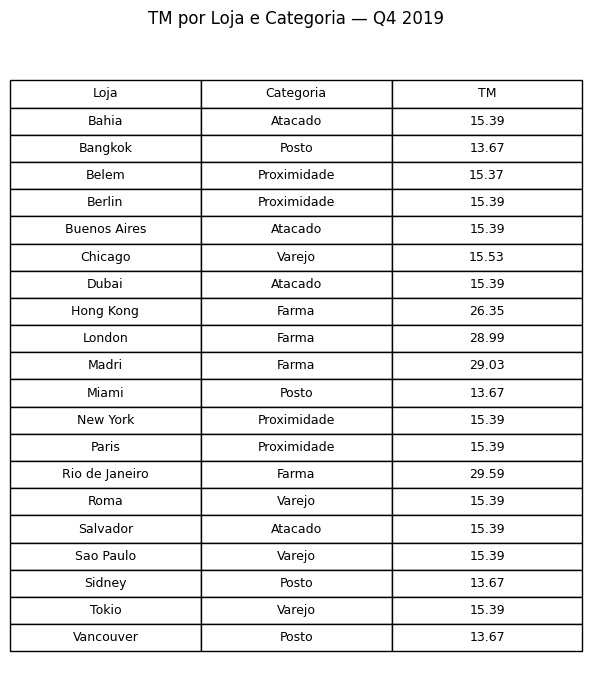

In [67]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 7))
ax.axis('off')

tabela = ax.table(
    cellText=df_tm.values,
    colLabels=df_tm.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.4)

plt.title('TM por Loja e Categoria — Q4 2019', pad=20)
plt.tight_layout()
plt.savefig('caso2.png', dpi=150, bbox_inches='tight')
plt.show()

**CASO 3 - GRÁFICO IMDB**

In [68]:
query = "SELECT * FROM IMDB_movies LIMIT 5;"
df_imdb = pd.read_sql(query, conn)
print(df_imdb.columns.tolist())

/tmp/ipykernel_2488/503488121.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_imdb = pd.read_sql(query, conn)


['Id', 'Title', 'Genre', 'Director', 'Actors', 'Year', 'Runtime', 'Rating', 'Votes', 'RevenueMillions', 'Metascore']


In [69]:
query = """
SELECT Title, Rating, RevenueMillions, Metascore
FROM IMDB_movies
WHERE RevenueMillions IS NOT NULL
AND Metascore IS NOT NULL;
"""
df_imdb = pd.read_sql(query, conn)
print(df_imdb.head())

/tmp/ipykernel_2488/2655144856.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_imdb = pd.read_sql(query, conn)


                     Title  Rating  RevenueMillions  Metascore
0  Guardians of the Galaxy     8.0            333.0         76
1               Prometheus     7.0            126.0         65
2                    Split     7.0            138.0         62
3                     Sing     7.0            270.0         59
4            Suicide Squad     6.0            325.0         40


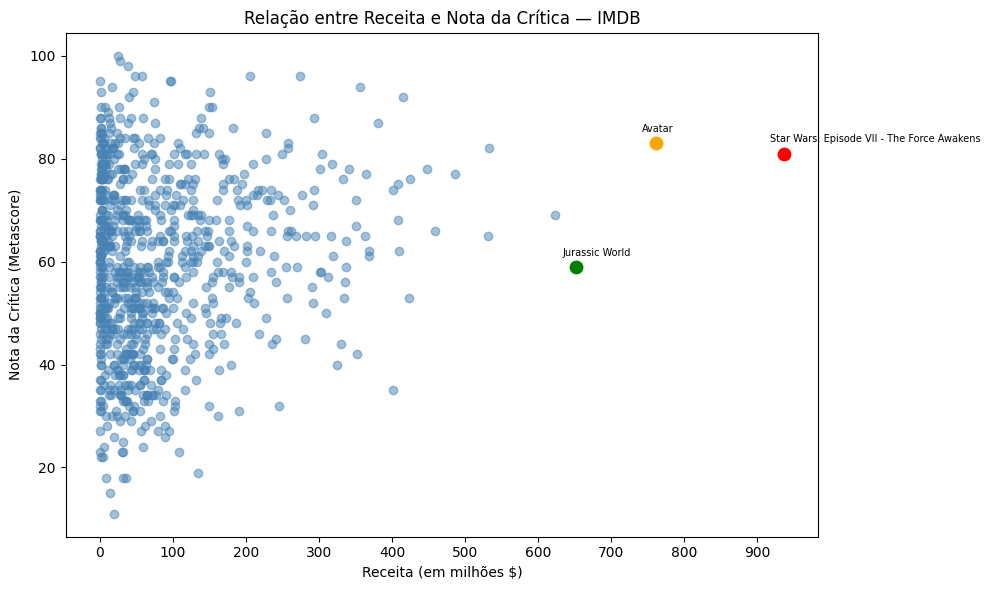

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_imdb['RevenueMillions'], df_imdb['Metascore'], alpha=0.5, color='steelblue')

# destaca os 3 maiores
destaques = df_top.values
cores = ['red', 'orange', 'green']
for i, (title, revenue, meta) in enumerate(destaques):
    ax.scatter(revenue, meta, color=cores[i], zorder=5, s=80)
    ax.annotate(title, (revenue, meta), textcoords="offset points", xytext=(-10, 8), fontsize=7)

ax.set_xlabel('Receita (em milhões $)')
ax.set_ylabel('Nota da Crítica (Metascore)')
ax.set_title('Relação entre Receita e Nota da Crítica — IMDB')
ax.set_xticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900])

plt.tight_layout()
plt.savefig('caso3.png', dpi=150, bbox_inches='tight')
plt.show()

Optei por gerar um gráfico de dispersão com o objetivo de avaliar a correlação entre a nota da crítica e a receita de bilheteria. Uma das hipóteses era verificar se filmes bem avaliados necessariamente gerariam maior receita.

O gráfico apresenta uma negativa dessa relação direta entre as duas variáveis, visto que, é possível observar que a maioria dos filmes concentram-se numa faixa de notas atribuídas de 40 à 80.

Os filmes com maiores receitas não obtiveram nota maior que 85, enquanto produções consideravelmente menores conseguiram atingiram notas acima de 90, mostrando uma subjetividade entre a opinião dos críticos e público geral.

Utilizei IA como suporte em partes específicas: na estruturação dos condicionais `if` e montagem dinâmica da query no Caso 1; na sintaxe do `merge`, conversão de datas e implementação do filtro para múltiplos itens no Caso 2; e na implementação do código matplotlib no Caso 3. A lógica das queries SQL, a escolha e interpretação das visualizações e o raciocínio analítico foram desenvolvidos por mim, com uso de IA apenas para resolução de erros de sintaxe.